# ISIC 2024 - Questions the score doesn't answer

The capstone ended with one number: a pAUC of 0.169 for the blend. That number says the model ranks lesions well
on average, but it doesn't say *why*, or where it stops working. In this notebook I look at six questions about
the model instead of trying to push the score higher.

1. How noisy is the score?
2. Does the model find cancer, or does it find the lesions a doctor already thought were suspicious?
3. Does it work at a hospital it has never seen?
4. How many lesions does a patient need for the "ugly duckling" features to help?
5. Is it equally good for different skin tones, ages and sexes?
6. Which cancer types does the image model find that the metadata model misses?

Almost everything here uses the out-of-fold predictions that were already saved by the other notebooks. Only
questions 2, 3 and 4 need some new LightGBM runs.

In [1]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')
from isic_pauc import p_auc_tpr
from features import build_features

DATA_DIR = '../data'
SEED = 42
N_FOLDS = 5

## Data
The full training metadata (this time including the columns that are only in the training data, because some
questions need the diagnosis), the folds and the saved out-of-fold predictions.

In [2]:
train = pd.read_csv(f'{DATA_DIR}/train-metadata.csv', low_memory=False)
test = pd.read_csv(f'{DATA_DIR}/test-metadata.csv', low_memory=False)
folds = pd.read_csv(f'{DATA_DIR}/folds.csv')
train = train.merge(folds[['isic_id', 'fold']], on='isic_id')

blend = pd.read_csv(f'{DATA_DIR}/oof_blend.csv')[['isic_id', 'lgbm_rank', 'cnn_rank', 'blend']]
stack = pd.read_csv(f'{DATA_DIR}/oof_stack.csv')[['isic_id', 'oof']].rename(columns={'oof': 'stack'})
lgbm = pd.read_csv(f'{DATA_DIR}/oof_lgbm.csv')[['isic_id', 'oof']].rename(columns={'oof': 'lgbm_prob'})

df = train.merge(blend, on='isic_id').merge(stack, on='isic_id').merge(lgbm, on='isic_id')
# every fold was predicted by a different model, so ranks are taken inside each fold
df['stack_rank'] = df.groupby('fold')['stack'].rank(pct=True)
df['blend_rank'] = df.groupby('fold')['blend'].rank(pct=True)
print(df.shape, df['target'].sum())

(401059, 63) 393


## Helper functions
In the other notebooks the pAUC was computed per fold and averaged. Here I often look at small groups (one
hospital, one cancer type) where a single fold has only a handful of cancers, so I pool all folds and compute
one pAUC on the per-fold ranks.

For the uncertainty I use a bootstrap over **patients**: draw patients with replacement, take all their lesions,
compute the score, repeat. Resampling patients and not lesions matters, because lesions of one patient are not
independent.

In [3]:
def pauc(d, col):
    return p_auc_tpr(d['target'].to_numpy(), d[col].to_numpy(), 0.80)


def bootstrap(d, cols, n=200, seed=0):
    """pAUC of every column in `cols` on n patient-level bootstrap samples. Returns an array (n, len(cols))."""
    rng = np.random.default_rng(seed)
    groups = list(d.groupby('patient_id').indices.values())
    y = d['target'].to_numpy()
    scores = {col: d[col].to_numpy() for col in cols}
    out = []
    while len(out) < n:
        idx = np.concatenate([groups[i] for i in rng.integers(0, len(groups), len(groups))])
        if y[idx].sum() < 5:
            continue
        out.append([p_auc_tpr(y[idx], scores[col][idx], 0.80) for col in cols])
    return np.array(out)


def ci(values):
    lo, hi = np.percentile(values, [2.5, 97.5])
    return f'{lo:.4f} to {hi:.4f}'


LGB_PARAMS = dict(n_estimators=300, learning_rate=0.05, num_leaves=31, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.8, random_state=SEED, verbose=-1)


def fit_predict(trn, val, features, neg_frac=0.01):
    """Same LightGBM as in 03_lightgbm: all malignant + a sample of the benign lesions."""
    neg = trn[trn['target'] == 0]
    if neg_frac < 1:
        neg = neg.sample(frac=neg_frac, random_state=SEED)
    trn = pd.concat([trn[trn['target'] == 1], neg])
    model = lgb.LGBMClassifier(**LGB_PARAMS)
    model.fit(trn[features], trn['target'])
    return model.predict_proba(val[features])[:, 1]

In [4]:
# sanity check: pooled pAUC should be close to the per-fold means from the other notebooks (0.1644 / 0.1432 / 0.1691)
for col in ['lgbm_rank', 'cnn_rank', 'blend_rank', 'stack_rank']:
    per_fold = [pauc(df[df['fold'] == f], col) for f in range(N_FOLDS)]
    print(f'{col:11s} per-fold mean {np.mean(per_fold):.4f}   pooled {pauc(df, col):.4f}')

lgbm_rank   per-fold mean 0.1644   pooled 0.1641


cnn_rank    per-fold mean 0.1432   pooled 0.1418


blend_rank  per-fold mean 0.1691   pooled 0.1687


stack_rank  per-fold mean 0.1703   pooled 0.1701


## 1. How noisy is the score?
There are only 393 cancers, and the pAUC only looks at the hardest 20% of them. So how much would the score
change if I had a slightly different set of patients?

In [5]:
cols = ['lgbm_rank', 'cnn_rank', 'blend_rank', 'stack_rank']
boot = bootstrap(df, cols, n=300)

noise = pd.DataFrame({
    'pAUC': [pauc(df, c) for c in cols],
    'bootstrap std': boot.std(axis=0),
    '95% interval': [ci(boot[:, i]) for i in range(len(cols))],
}, index=['LightGBM', 'CNN', 'Blend', 'Stacking'])
noise.round(4)

,pAUC,bootstrap std,95% interval
LightGBM,0.1641,0.0043,0.1539 to 0.1713
CNN,0.1418,0.0062,0.1306 to 0.1548
Blend,0.1687,0.0039,0.1601 to 0.1754
Stacking,0.1701,0.0039,0.1624 to 0.1766


In [6]:
# differences on the SAME bootstrap samples (paired), which is much less noisy than comparing two intervals
pairs = {'Blend - LightGBM': (2, 0), 'Blend - CNN': (2, 1), 'Stacking - Blend': (3, 2)}
rows = {}
for name, (a, b) in pairs.items():
    diff = boot[:, a] - boot[:, b]
    rows[name] = {'difference': pauc(df, cols[a]) - pauc(df, cols[b]), '95% interval': ci(diff),
                  'share of samples > 0': (diff > 0).mean()}
pd.DataFrame(rows).T

,difference,95% interval,share of samples > 0
Blend - LightGBM,0.004671,0.0020 to 0.0080,1.0
Blend - CNN,0.026988,0.0165 to 0.0350,1.0
Stacking - Blend,0.001314,-0.0018 to 0.0047,0.77


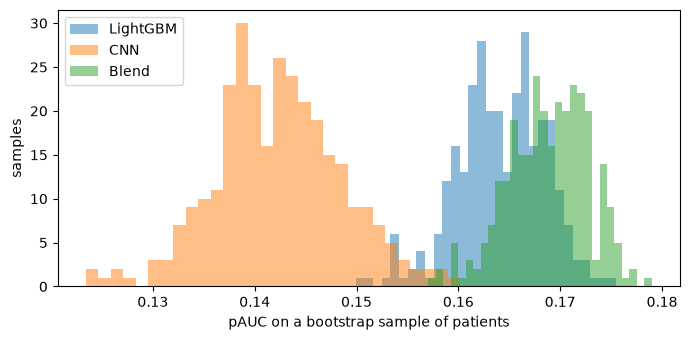

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for i, name in enumerate(['LightGBM', 'CNN', 'Blend']):
    ax.hist(boot[:, i], bins=30, alpha=0.5, label=name)
ax.set_xlabel('pAUC on a bootstrap sample of patients')
ax.set_ylabel('samples')
ax.legend()
plt.tight_layout()
plt.show()

- One standard deviation of the blend's pAUC is about 0.004, and the 95% interval goes from 0.160 to 0.175. So the
  third decimal of every score in this project is basically noise.
- The blend really is better than LightGBM alone: the difference is small (+0.0047) but it was above 0 in every
  bootstrap sample. Looking at the difference on the same samples is what makes this visible, the two intervals
  on their own overlap a lot.
- Stacking vs blend (+0.0013) is not a real difference, the interval goes from -0.002 to +0.005. That agrees with
  what I decided in `06_stacking`, but now there is a number behind it.
- This also puts the Kaggle leaderboard in perspective. The hidden test set is bigger, so its noise is smaller
  than here, but teams that are 0.001 apart are not really different.

## 2. Cancer, or "a doctor thought this looked suspicious"?
Every malignant lesion in the data was biopsied, that is how we know it is malignant. But almost none of the
benign lesions were: they are "benign" because nobody saw a reason to cut them out. Only the benign lesions
that have a `lesion_id` went through a biopsy.

So the model could get a high score just by learning what makes a doctor suspicious. The fair test is to compare
the cancers only against the benign lesions that were also biopsied, because those looked suspicious too.

In [8]:
df['biopsied'] = df['lesion_id'].notna()
df['group'] = np.where(df['target'] == 1, 'malignant', np.where(df['biopsied'], 'benign, biopsied', 'benign, not biopsied'))
print(df['group'].value_counts())

def subsets():
    mal = df['target'] == 1
    return {
        'malignant vs all benign': df,
        'malignant vs benign not biopsied': df[mal | ~df['biopsied']],
        'malignant vs benign biopsied': df[df['biopsied']],
    }


rows = {}
for name, d in subsets().items():
    rows[name] = {col.replace('_rank', ''): pauc(d, col) for col in ['lgbm_rank', 'cnn_rank', 'blend_rank']}
    rows[name]['blend AUC'] = roc_auc_score(d['target'], d['blend_rank'])
    rows[name]['benign lesions'] = int((d['target'] == 0).sum())
biopsy_table = pd.DataFrame(rows).T
biopsy_table.round(4)

group
benign, not biopsied    379001
benign, biopsied         21665
malignant                  393
Name: count, dtype: int64


,lgbm,cnn,blend,blend AUC,benign lesions
malignant vs all benign,0.1641,0.1418,0.1687,0.9593,400666.0
malignant vs benign not biopsied,0.1674,0.1440,0.1717,0.9640,379001.0
malignant vs benign biopsied,0.1067,0.1018,0.1178,0.8757,21665.0


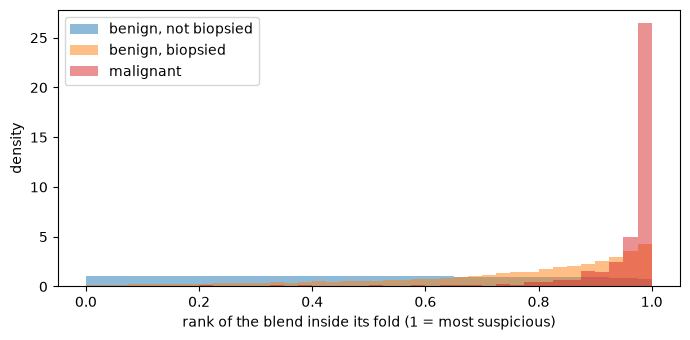

median rank: {'benign, biopsied': 0.821, 'benign, not biopsied': 0.481, 'malignant': 0.989}


In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for name, color in [('benign, not biopsied', 'tab:blue'), ('benign, biopsied', 'tab:orange'), ('malignant', 'tab:red')]:
    ax.hist(df.loc[df['group'] == name, 'blend_rank'], bins=40, range=(0, 1), density=True, alpha=0.5, label=name,
            color=color)
ax.set_xlabel('rank of the blend inside its fold (1 = most suspicious)')
ax.set_ylabel('density')
ax.legend()
plt.tight_layout()
plt.show()

print('median rank:', df.groupby('group')['blend_rank'].median().round(3).to_dict())

This is the result that surprised me most.

- Against the benign lesions that were never biopsied, the blend scores 0.172. Against the biopsied ones it drops
  to **0.118** (AUC 0.96 -> 0.88).
- The histogram shows why: the model already puts the biopsied benign lesions high (median rank 0.82, compared to
  0.48 for the rest). So the model and the doctors mostly agree on what looks suspicious.
- The headline number of 0.169 is almost the same as the "not biopsied" number, because 95% of the benign lesions
  were never biopsied. It mostly measures how well the model separates cancers from lesions nobody was worried
  about.

It doesn't mean the model is useless: an AUC of 0.88 on the hard cases is still far better than guessing, and
finding the suspicious lesions among hundreds is the triage job I described. But it can't replace the biopsy
decision, and the score would look much less impressive if the benchmark was "lesions a dermatologist wanted to
check".

### Training on the hard cases
If the normal model mostly learned "suspicious vs not suspicious", a model that only sees biopsied lesions during
training has to learn the harder thing: which of the suspicious lesions are really cancer. Same features, same
folds, but the benign lesions in training are the biopsied ones only (all of them, no downsampling).

In [10]:
feat_df, features = build_features(train, test)
feat_df['biopsied'] = train['lesion_id'].notna().to_numpy()
assert (feat_df['isic_id'].to_numpy() == df['isic_id'].to_numpy()).all()   # same row order as df

df['lgbm_biopsy_only'] = np.nan
for fold in range(N_FOLDS):
    trn = feat_df[(feat_df['fold'] != fold) & feat_df['biopsied']]
    val = feat_df[feat_df['fold'] == fold]
    df.loc[val.index, 'lgbm_biopsy_only'] = fit_predict(trn, val, features, neg_frac=1)
df['lgbm_biopsy_only_rank'] = df.groupby('fold')['lgbm_biopsy_only'].rank(pct=True)

rows = {}
for name, d in subsets().items():
    rows[name] = {'normal LightGBM': pauc(d, 'lgbm_rank'), 'trained on biopsied only': pauc(d, 'lgbm_biopsy_only_rank')}
pd.DataFrame(rows).T.round(4)

,normal LightGBM,trained on biopsied only
malignant vs all benign,0.1641,0.0909
malignant vs benign not biopsied,0.1674,0.0890
malignant vs benign biopsied,0.1067,0.1241


- On the hard cases the specialised model is better (0.124 vs 0.107), so there is something to learn about
  cancer vs suspicious-but-benign that the normal model doesn't pick up.
- On everything else it is much worse (0.091 vs 0.164), because it never saw an ordinary mole during training.

So these are two different problems: "which lesions are worth a closer look" and "which of those are cancer".
One model trained on the whole dataset mostly solves the first. A second model for the second step could be a
good addition, but with only about 20,000 biopsied lesions I didn't go further here.

## 3. A hospital the model has never seen
The data comes from 7 hospitals (`attribution`). My folds are split by patient, so every hospital is in training
and validation at the same time. A new clinic would have a different camera setup and different patients.

Here I leave one hospital out completely, train LightGBM on the other six and predict the held-out one. For
comparison, the "seen" column is the normal out-of-fold prediction for the same lesions. I show the AUC next to
the pAUC, because some hospitals have so few cancers that the pAUC is not reliable.

In [11]:
feat_df['attribution'] = train['attribution'].to_numpy()
short = {
    'Memorial Sloan Kettering Cancer Center': 'New York (MSK)',
    'Frazer Institute, The University of Queensland, Dermatology Research Centre': 'Queensland',
    'University Hospital of Basel': 'Basel',
    'ACEMID MIA': 'ACEMID (Australia)',
    'ViDIR Group, Department of Dermatology, Medical University of Vienna': 'Vienna',
}
feat_df['hospital'] = feat_df['attribution'].map(short)
feat_df.loc[feat_df['attribution'].str.contains('Barcelona'), 'hospital'] = 'Barcelona'
feat_df.loc[feat_df['attribution'].str.contains('Athens'), 'hospital'] = 'Athens'
df['hospital'] = feat_df['hospital'].to_numpy()

df['lgbm_unseen'] = np.nan
for hospital in feat_df['hospital'].unique():
    held_out = feat_df['hospital'] == hospital
    df.loc[held_out.to_numpy(), 'lgbm_unseen'] = fit_predict(feat_df[~held_out], feat_df[held_out], features)

rows = {}
for hospital, d in df.groupby('hospital'):
    rows[hospital] = {
        'patients': d['patient_id'].nunique(), 'cancers': int(d['target'].sum()),
        'pAUC seen': pauc(d, 'lgbm_prob'), 'pAUC unseen': pauc(d, 'lgbm_unseen'),
        'AUC seen': roc_auc_score(d['target'], d['lgbm_prob']), 'AUC unseen': roc_auc_score(d['target'], d['lgbm_unseen']),
    }
hospital_table = pd.DataFrame(rows).T.sort_values('cancers', ascending=False)
hospital_table['pAUC change'] = hospital_table['pAUC unseen'] - hospital_table['pAUC seen']
hospital_table.round(4)

,patients,cancers,pAUC seen,pAUC unseen,AUC seen,AUC unseen,pAUC change
New York (MSK),398.0,174.0,0.1744,0.1514,0.9689,0.9430,-0.0231
Queensland,176.0,81.0,0.1591,0.1540,0.9386,0.9328,-0.0052
Barcelona,163.0,72.0,0.1703,0.1521,0.9575,0.9347,-0.0183
ACEMID (Australia),44.0,33.0,0.1593,0.1485,0.9381,0.9303,-0.0107
Vienna,15.0,14.0,0.1776,0.1813,0.9537,0.9583,0.0037
Basel,230.0,13.0,0.1108,0.1244,0.8987,0.9114,0.0136
Athens,16.0,6.0,0.0648,0.0480,0.8595,0.8455,-0.0169


In [12]:
# all hospitals together: every lesion predicted by a model that never saw its hospital.
# ranks inside each hospital, the same way the folds are handled
df['unseen_rank'] = df.groupby('hospital')['lgbm_unseen'].rank(pct=True)
df['seen_rank'] = df.groupby('hospital')['lgbm_prob'].rank(pct=True)
b = bootstrap(df, ['seen_rank', 'unseen_rank'], n=300)
print(f"seen:   {pauc(df, 'seen_rank'):.4f}")
print(f"unseen: {pauc(df, 'unseen_rank'):.4f}")
print('difference (unseen - seen):', round(pauc(df, 'unseen_rank') - pauc(df, 'seen_rank'), 4), ' 95% interval:', ci(b[:, 1] - b[:, 0]))

seen:   0.1639
unseen: 0.1499


difference (unseen - seen): -0.0139  95% interval: -0.0193 to -0.0090


- With every lesion predicted by a model that never saw its hospital, the pAUC goes from 0.164 to **0.150**. The
  interval of the difference (-0.019 to -0.009) doesn't include 0, so the drop is real.
- The three biggest hospitals all lose (New York -0.023, Barcelona -0.018, Queensland -0.005). Vienna, Basel and
  Athens have 6 to 14 cancers each, so I wouldn't read anything into their numbers.
- One thing I can't separate: leaving a hospital out also removes training data. Without New York the model
  trains on 219 cancers instead of about 314. So part of the drop is "less data" and not only "new hospital".

Still, 0.150 is a more honest estimate for a new clinic than the 0.164 from my patient folds. It is also a reason
why I'm glad I left `attribution` out of the features: a model that uses the hospital name has nothing to work
with at a new hospital.

## 4. How many lesions does the "ugly duckling" need?
The patient-normalized features compare a lesion to the patient's other lesions. That should work better when a
patient has many lesions to compare with. To check, I train LightGBM once without those features (v2 from
`03_lightgbm`) and compare it with the normal model (v3) for patients with few, medium and many lesions.

In [13]:
features_v2 = [f for f in features if not f.endswith('_pnorm') and f != 'patient_lesion_count']
print(len(features), 'features with,', len(features_v2), 'without the patient features')

df['lgbm_v2'] = np.nan
for fold in range(N_FOLDS):
    val = feat_df[feat_df['fold'] == fold]
    df.loc[val.index, 'lgbm_v2'] = fit_predict(feat_df[feat_df['fold'] != fold], val, features_v2)
df['v2_rank'] = df.groupby('fold')['lgbm_v2'].rank(pct=True)

df['n_lesions'] = df.groupby('patient_id')['patient_id'].transform('count')
# three groups with about the same number of cancers in each
edges = df.loc[df['target'] == 1, 'n_lesions'].quantile([1 / 3, 2 / 3]).round(-1).tolist()
df['lesion_group'] = pd.cut(df['n_lesions'], [0] + edges + [np.inf],
                            labels=[f'up to {edges[0]:.0f}', f'{edges[0]:.0f} to {edges[1]:.0f}', f'more than {edges[1]:.0f}'])

rows = {}
for name, d in list(df.groupby('lesion_group', observed=True)) + [('all patients', df)]:
    b = bootstrap(d, ['v2_rank', 'lgbm_rank'], n=300)
    rows[name] = {'patients': d['patient_id'].nunique(), 'cancers': int(d['target'].sum()),
                  'without': pauc(d, 'v2_rank'), 'with': pauc(d, 'lgbm_rank'),
                  'gain': pauc(d, 'lgbm_rank') - pauc(d, 'v2_rank'), '95% interval of the gain': ci(b[:, 1] - b[:, 0])}
duckling_table = pd.DataFrame(rows).T
duckling_table

57 features with, 44 without the patient features


,patients,cancers,without,with,gain,95% interval of the gain
up to 310,615,131,0.151294,0.152709,0.001414,-0.0069 to 0.0105
310 to 680,273,131,0.165055,0.163862,-0.001193,-0.0083 to 0.0063
more than 680,154,131,0.160194,0.17085,0.010655,0.0010 to 0.0205
all patients,1042,393,0.159389,0.164076,0.004686,-0.0006 to 0.0097


- For patients with more than 680 lesions the patient features add +0.011, and the interval (0.001 to 0.021) is
  above 0.
- For patients with fewer lesions there is no measurable gain (+0.001 and -0.001, both intervals around 0).
- Over all patients the gain is +0.0047 with an interval from -0.0006 to 0.0097, so it is not even clearly above
  0 on its own. In `03_lightgbm` I reported this step as an improvement (0.1597 -> 0.1644), which was a bit too
  confident.

It fits the idea behind the feature: you can only spot the odd one out when there are many to compare with.
In practice it means the model depends on a full-body scan with hundreds of lesions. For someone who uploads
photos of a few moles, these features would do little.

## 5. Skin tone, age and sex
The dataset has no skin type column. As a rough replacement I use the color of the skin *around* the lesion
(`tbp_lv_Lext`, `tbp_lv_Bext`) to compute the ITA angle, which is a standard way to measure skin tone from color
(higher = lighter). I take the median over all lesions of a patient and split the patients into three groups.

These patients come from skin cancer clinics in Europe, the US and Australia, so "darker" here means the darkest
third of a mostly light-skinned group, not dark skin in general.

In [14]:
df['ita'] = np.degrees(np.arctan2(df['tbp_lv_Lext'] - 50, df['tbp_lv_Bext']))
patient_ita = df.groupby('patient_id')['ita'].median()
tone = pd.qcut(patient_ita, 3, labels=['darker third', 'middle third', 'lighter third'])
df['tone_group'] = df['patient_id'].map(tone)
print(patient_ita.groupby(tone, observed=True).agg(['min', 'max']).round(1))

df['age_group'] = pd.cut(df['age_approx'], [0, 50, 65, 100], labels=['up to 50', '55 to 65', '70 and older'])


def group_table(col):
    rows = {}
    for name, d in df.groupby(col, observed=True):
        b = bootstrap(d, ['blend_rank'], n=300)
        rows[name] = {'patients': d['patient_id'].nunique(), 'cancers': int(d['target'].sum()),
                      'cancers per 1,000 lesions': 1000 * d['target'].mean(),
                      'blend pAUC': pauc(d, 'blend_rank'), '95% interval': ci(b[:, 0])}
    return pd.DataFrame(rows).T


group_table('tone_group')

                min   max
ita                      
darker third  -49.7  -0.4
middle third   -0.3  19.1
lighter third  19.1  42.4


,patients,cancers,"cancers per 1,000 lesions",blend pAUC,95% interval
darker third,348,144,0.737833,0.169886,0.1595 to 0.1784
middle third,347,101,0.872427,0.160337,0.1463 to 0.1743
lighter third,347,148,1.642182,0.17559,0.1595 to 0.1870


In [15]:
group_table('sex')

,patients,cancers,"cancers per 1,000 lesions",blend pAUC,95% interval
female,458,109,0.879061,0.159514,0.1461 to 0.1721
male,551,274,1.031836,0.173018,0.1649 to 0.1811


In [16]:
group_table('age_group')

,patients,cancers,"cancers per 1,000 lesions",blend pAUC,95% interval
up to 50,491,79,0.605067,0.162446,0.1351 to 0.1812
55 to 65,393,199,1.190348,0.170192,0.1616 to 0.1775
70 and older,167,112,1.114217,0.170889,0.1556 to 0.1829


- I don't see a group where the model clearly fails. All intervals overlap.
- The lighter third has about twice as many cancers per lesion as the darker third (1.6 vs 0.7 per 1,000), but
  the pAUC is similar (0.176 vs 0.170).
- Women have a lower score than men (0.160 vs 0.173). The intervals overlap and there are only 109 cancers in
  women, so I can't say if this is real. It would be worth checking with more data.
- Patients up to 50 have the widest interval (0.135 to 0.181) because only 79 of the cancers are theirs.

The honest summary is that this dataset can't answer the fairness question well. The groups are too small, and
there are almost no patients with dark skin in it at all.

## 6. Which cancers does each model find?
"Malignant" is three different cancers in this data: basal cell carcinoma, melanoma and squamous cell carcinoma.
The blend worked because LightGBM and the CNN disagree, so I want to know if they disagree on particular types.

For every type I count how many of its lesions each model puts in the top 5% most suspicious lesions of the
fold (that is roughly the share a doctor would have to look at when the blend finds 80% of the cancers).

In [17]:
def cancer_type(x):
    if not isinstance(x, str):
        return np.nan
    if 'Basal' in x:
        return 'basal cell carcinoma'
    if 'Squamous' in x:
        return 'squamous cell carcinoma'
    return 'melanoma'


df['cancer_type'] = df['iddx_3'].where(df['target'] == 1).map(cancer_type)
TOP = 0.95

rows = {}
cancers = df[df['target'] == 1]
for name, d in list(cancers.groupby('cancer_type')) + [('all cancers', cancers)]:
    rows[name] = {
        'lesions': len(d),
        'LightGBM': (d['lgbm_rank'] > TOP).mean(), 'CNN': (d['cnn_rank'] > TOP).mean(),
        'Blend': (d['blend_rank'] > TOP).mean(),
        'only LightGBM': ((d['lgbm_rank'] > TOP) & (d['cnn_rank'] <= TOP)).mean(),
        'only CNN': ((d['cnn_rank'] > TOP) & (d['lgbm_rank'] <= TOP)).mean(),
        'neither': ((d['lgbm_rank'] <= TOP) & (d['cnn_rank'] <= TOP)).mean(),
    }
type_table = pd.DataFrame(rows).T
type_table.round(2)

,lesions,LightGBM,CNN,Blend,only LightGBM,only CNN,neither
basal cell carcinoma,163.0,0.80,0.66,0.79,0.22,0.07,0.12
melanoma,157.0,0.73,0.59,0.77,0.22,0.08,0.18
squamous cell carcinoma,73.0,0.81,0.73,0.81,0.16,0.08,0.11
all cancers,393.0,0.78,0.64,0.79,0.21,0.08,0.15


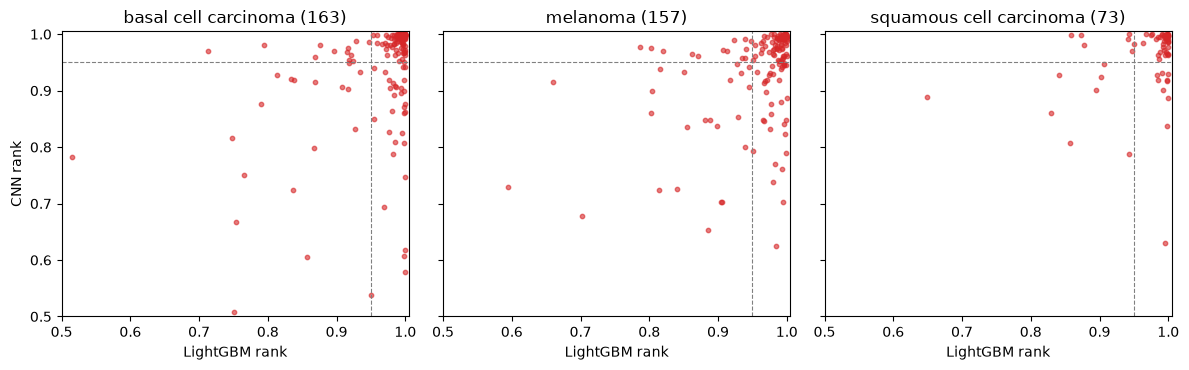

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)
for ax, (name, d) in zip(axes, cancers.groupby('cancer_type')):
    ax.scatter(d['lgbm_rank'], d['cnn_rank'], s=10, color='tab:red', alpha=0.6)
    ax.axvline(TOP, color='grey', linestyle='--', linewidth=0.8)
    ax.axhline(TOP, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlim(0.5, 1.005)
    ax.set_ylim(0.5, 1.005)
    ax.set_title(f'{name} ({len(d)})')
    ax.set_xlabel('LightGBM rank')
axes[0].set_ylabel('CNN rank')
plt.tight_layout()
plt.show()

- LightGBM puts 78% of the cancers in the top 5%, the CNN 64%. 8% are found only by the CNN and 21% only by
  LightGBM. 15% are missed by both.
- I expected the CNN to be good at one type, but the pattern is about the same for all three. The CNN adds its 7
  to 8% everywhere.
- Melanoma is the hardest: 18% of the melanomas are in nobody's top 5%, compared to 11 to 12% for the other two.
  That is the type where a miss is most dangerous.
- At this one threshold the blend (79%) is barely better than LightGBM (78%). Its gain in pAUC must come from
  moving cancers up inside and around the top 5%, not from many new ones crossing this line.

## Summary

| Question | Short answer |
|---|---|
| How noisy is the score? | About ±0.004 (one std). Blend > LightGBM is real, stacking vs blend is not. |
| Cancer or "looks suspicious"? | Against biopsied benign lesions the pAUC drops from 0.169 to 0.118. |
| Unseen hospital? | 0.164 -> 0.150 for LightGBM, the drop is real. |
| Ugly duckling and lesion count? | The gain only shows for patients with more than about 680 lesions. |
| Skin tone, age, sex? | No clear differences, but the groups are too small to be sure. |
| Cancer types? | The CNN adds about 8% everywhere. Melanoma is missed most often. |

What I take from this: the score in my report is correct, but it describes an easier job than it sounds like.
The model is good at sorting out lesions nobody would worry about, at a hospital it knows, for patients with a
full-body scan. Each of those three conditions costs something when it is removed, and the biggest one is the
first.

If I continued this project, I would not start with a bigger image model. I would evaluate on the biopsied
lesions as a second metric and build the two-step model from question 2.